In [21]:
import numpy as np 
import scipy.stats as st
import pymc as pm
import matplotlib.pyplot as plt 
import arviz as az 
import pickle 
import pytensor.tensor as pt
import pytensor.scan as scan
import pytensor
from pytensor.printing import Print
from pytensor import function
import corner 

In [22]:
Nobs=10000

In [23]:
np.random.seed(123)
def plotter2(x_obs,y_obs,x_name,y_name):
    fig = plt.figure(figsize=(8, 8))
    grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)
    main_ax = fig.add_subplot(grid[1:4, 0:3])
    main_ax.scatter(x_obs, y_obs, alpha=0.6, color='darkorange', s=25)
    main_ax.set_title("Scatter Plot of "+x_name+" vs "+ y_name , fontsize=14)
    main_ax.set_xlabel(x_name, fontsize=12)
    main_ax.set_ylabel(y_name, fontsize=12)
    main_ax.grid(True, linestyle='--', alpha=0.6)

    x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
    x_hist.hist(x_obs, bins=30, color='gold', edgecolor='k')
    x_hist.set_title("Histogram of "+x_name, fontsize=12)
    x_hist.grid(True, linestyle='--', alpha=0.5)

    y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
    y_hist.hist(y_obs, bins=30, orientation='horizontal', color='tomato', edgecolor='k')
    y_hist.set_title("Histogram of  "+y_name, fontsize=12)
    y_hist.grid(True, linestyle='--', alpha=0.5)

    plt.show()
def plotter1(x,x_name):
    plt.hist(x,bins=50,color='blue')
    plt.title("Histogram of "+x_name)
    plt.xlabel(x_name)
    plt.ylabel("Pm("+x_name+")")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

True variable Generation:
$$

\begin{pmatrix}
x_i \\
y_i
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
\mu_x \\
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 & \rho\,\sigma_x\sigma_y \\
\rho\,\sigma_x\sigma_y & \sigma_y^2
\end{pmatrix}
\right)
$$

In [24]:
mu_t_x=0
mu_t_y=0
sigma_t_y=1
sigma_t_x=1
p_t=0.8
cov = [
    [sigma_t_x**2, p_t * sigma_t_x * sigma_t_y],
    [p_t * sigma_t_x * sigma_t_y, sigma_t_y**2]
]

mean = [mu_t_x, mu_t_y]

x, y = np.random.multivariate_normal(mean, cov, Nobs).T

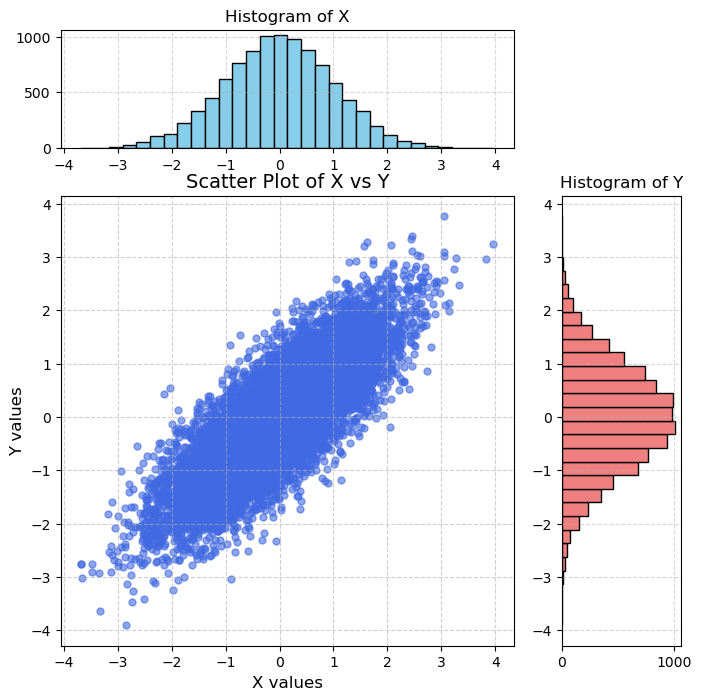

In [25]:

fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)

main_ax = fig.add_subplot(grid[1:4, 0:3])
main_ax.scatter(x, y, alpha=0.6, color='royalblue', s=25)
main_ax.set_title("Scatter Plot of X vs Y", fontsize=14)
main_ax.set_xlabel("X values", fontsize=12)
main_ax.set_ylabel("Y values", fontsize=12)
main_ax.grid(True, linestyle='--', alpha=0.6)

x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
x_hist.hist(x, bins=30, color='skyblue', edgecolor='k')
x_hist.set_title("Histogram of X", fontsize=12)
x_hist.grid(True, linestyle='--', alpha=0.5)

y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
y_hist.hist(y, bins=30, orientation='horizontal', color='lightcoral', edgecolor='k')
y_hist.set_title("Histogram of Y", fontsize=12)
y_hist.grid(True, linestyle='--', alpha=0.5)

plt.show()

Observed Variable Generation : 

$$
\begin{pmatrix}
x_i^{\mathrm{obs}} \\
y_i^{\mathrm{obs}}
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
x_i \\
y_i
\end{pmatrix},
\begin{pmatrix}
\sigma_{x,i}^2 & \rho_2\,\sigma_{x,i}\sigma_{y,i} \\
\rho_2\,\sigma_{x,i}\sigma_{y,i} & \sigma_{y,i}^2
\end{pmatrix}
\right)
$$

Imposing truncation , that is , we are defining a region in the x-y plane where our observed variable can exist.
Here the region is defined as 
$$
\mathcal{Region} \equiv (x_i^{obs})^2> (y_i^{obs})^2
$$


$$
\textbf{Now observed Quantities}
$$
$$
Y_i^{\text{obs}},X_i^{\text{obs}},\sigma_{Y_i}^{\text{obs}},\sigma_{X_i}^{\text{obs}}
$$
$$


In [26]:
x_obs = np.zeros(Nobs)
y_obs = np.zeros(Nobs)
sigma_obs_y = abs(np.random.normal(3, 2, Nobs))*0+2
sigma_obs_x = abs(np.random.normal(3, 2, Nobs))*0+2
p2 = 0.8  
r=3
for i in range(Nobs):
    cov = [
        [sigma_obs_x[i]**2,              p2 * sigma_obs_x[i] * sigma_obs_y[i]],
        [p2 * sigma_obs_x[i] * sigma_obs_y[i], sigma_obs_y[i]**2]
    ]
    mean = [x[i], y[i]]    # intrinsic x,y for point i

    x_temp, y_temp = np.random.multivariate_normal(mean, cov)
    x_obs[i], y_obs[i] = x_temp, y_temp

mask = x_obs**2>y_obs**2


x_obs        = x_obs[mask]
y_obs        = y_obs[mask]
sigma_obs_x1 = sigma_obs_x[mask]
sigma_obs_y1 = sigma_obs_y[mask]
sigma_obs_x=np.mean(sigma_obs_x1)
sigma_obs_y=np.mean(sigma_obs_y1)
     




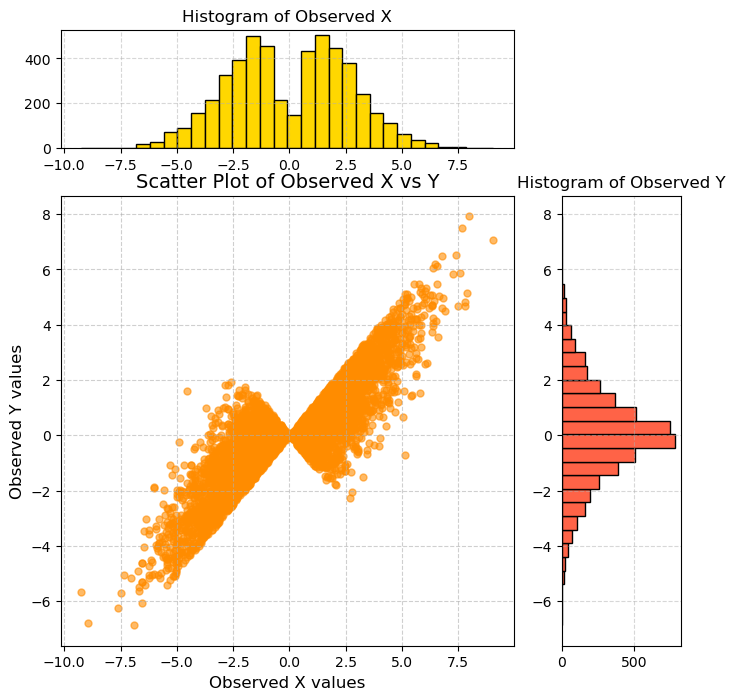

In [27]:
fig = plt.figure(figsize=(8, 8))
grid = plt.GridSpec(4, 4, hspace=0.4, wspace=0.4)
main_ax = fig.add_subplot(grid[1:4, 0:3])
main_ax.scatter(x_obs, y_obs, alpha=0.6, color='darkorange', s=25)
main_ax.set_title("Scatter Plot of Observed X vs Y", fontsize=14)
main_ax.set_xlabel("Observed X values", fontsize=12)
main_ax.set_ylabel("Observed Y values", fontsize=12)
main_ax.grid(True, linestyle='--', alpha=0.6)

x_hist = fig.add_subplot(grid[0, 0:3], sharex=main_ax)
x_hist.hist(x_obs, bins=30, color='gold', edgecolor='k')
x_hist.set_title("Histogram of Observed X", fontsize=12)
x_hist.grid(True, linestyle='--', alpha=0.5)

y_hist = fig.add_subplot(grid[1:4, 3], sharey=main_ax)
y_hist.hist(y_obs, bins=30, orientation='horizontal', color='tomato', edgecolor='k')
y_hist.set_title("Histogram of Observed Y", fontsize=12)
y_hist.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [28]:
Nobs=len(y_obs)
print(Nobs)

5033


<ErrorbarContainer object of 3 artists>

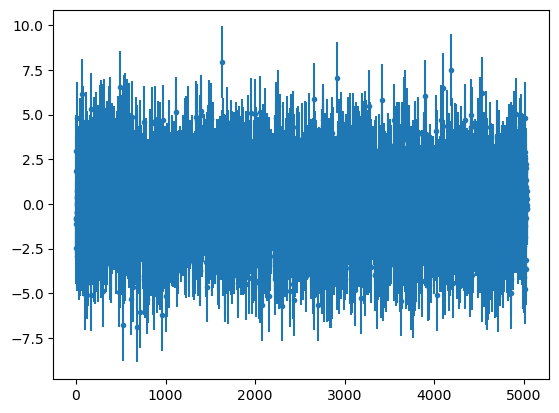

In [29]:
plt.errorbar(np.arange(0,Nobs,1), y_obs, yerr=sigma_obs_y, fmt='.', label='data')

<ErrorbarContainer object of 3 artists>

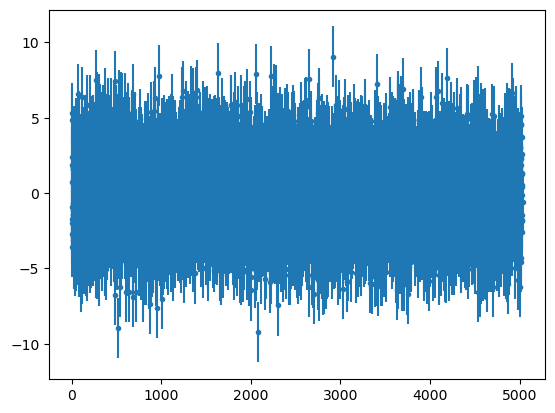

In [30]:
plt.errorbar(np.arange(0,Nobs,1), x_obs, yerr=sigma_obs_x, fmt='.', label='data')

In [31]:
cov3=np.cov(x_obs,y_obs)[0,1]/(np.std(x_obs)*np.std(y_obs))
print(cov3)

0.8677817028564079



$$
\textbf{Priors}
$$

$$
\mu_x \sim \mathcal{U}(-5, 5)
$$
$$
\mu_y \sim \mathcal{U}(-5, 5)
$$
$$
\sigma_x \sim \mathcal{U}(0, 10)
$$
$$
\sigma_y \sim \mathcal{U}(0, 10)
$$


$$
\textbf{Full Likelihood Expression}
$$

$$
\vec{\Omega} = (\mu_x, \mu_y, \sigma_x, \sigma_y, \rho)
$$

$$
P(\vec{\Omega} \, | \, \vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}}) 
\propto P(\vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}} \, | \, \vec{\Omega}) \, P(\vec{\Omega})
$$

$$
\mathcal{L}(\vec{x}^{\, \mathrm{obs}}, \vec{y}^{\, \mathrm{obs}} \, | \, \vec{\Omega}) 
= \prod_{i=1}^{N_{\mathrm{obs}}} 
\iint P(x_i^{\, \mathrm{obs}}, y_i^{\, \mathrm{obs}} \, | \, x_i,y_i) 
P(x_i, y_i \, | \, \vec{\Omega}) \, dx_i \, dy_i
$$


Now truncating such that $x_{obs},y_{obs} \in \mathcal{Region}$, where the region is arbritary
$$
\mathcal{L}(\vec{x}^{\,\mathrm{obs}}, \vec{y}^{\,\mathrm{obs}} \mid \vec{\Omega})
= \prod_{i=1}^{N_{\mathrm{obs}}} \frac{


\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 


\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$
$$
or, \text{     }\mathcal{L}(\vec{x}^{\,\mathrm{obs}}, \vec{y}^{\,\mathrm{obs}} \mid \vec{\Omega})
= \prod_{i=1}^{N_{\mathrm{obs}}} \frac{
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$


Posterior :
$$
P\left(\Omega \mid x^{\text{obs}}, y^{\text{obs}}, \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\right)
\propto
P(\Omega) \, \mathcal{L}(x^{\text{obs}}, y^{\text{obs}} \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\mid \Omega)
$$
$$
P\left(\Omega \mid x^{\text{obs}}, y^{\text{obs}}, \sigma_y^{\text{obs}}, \sigma_x^{\text{obs}}\right)
\propto
P(\mu_X)P(\mu_Y) P(\sigma_X) P(\sigma_Y) \, \\ \times \prod_{i=1}^{N_{\mathrm{obs}}} \frac{
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right)}
{
    \displaystyle \iint_{x_{obs},y_{obs} \in \mathcal{Region}} 
\mathcal{N}_{x_i^{\mathrm{obs}},y_i^{\mathrm{obs}}}
\!\left(
\begin{pmatrix}
\mu_x \\[4pt]
\mu_y
\end{pmatrix},
\begin{pmatrix}
\sigma_x^2 + (\sigma_{x,i}^{\mathrm{obs}})^2
&
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
\\[6pt]
\rho\sigma_x\sigma_y+ \rho_2 \sigma_{x,i}^{\mathrm{obs}}\sigma_{y,i}^{\mathrm{obs}}
&
\sigma_y^2 + (\sigma_{y,i}^{\mathrm{obs}})^2
\end{pmatrix}
\right) dx_{obs}dy_{obs}
}
$$

For this example , the region is defined as :

$$
\mathcal{Region} \equiv (x_i^{obs})^2> (y_i^{obs})^2
$$

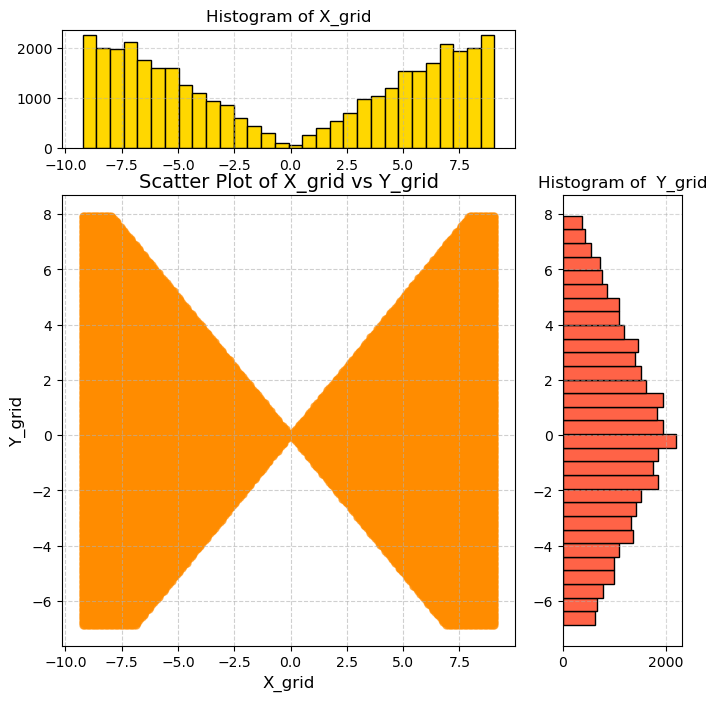

In [32]:

X22 = None
Y22 = None
N_grid=250 
X_np = np.linspace(np.min(x_obs), np.max(x_obs), N_grid)
Y_np = np.linspace(np.min(y_obs), np.max(y_obs), N_grid)

Xg_np, Yg_np = np.meshgrid(X_np, Y_np, indexing="ij")

M_np = (Xg_np**2>Yg_np**2)

valid = M_np.ravel()          
X_flat = Xg_np.ravel()[valid]
Y_flat = Yg_np.ravel()[valid]

X22 = pt.as_tensor_variable(X_flat)
Y22 = pt.as_tensor_variable(Y_flat)

dx = X_np[1] - X_np[0]
dy = Y_np[1] - Y_np[0]
area_elem = dx * dy
plotter2(X_flat,Y_flat,"X_grid","Y_grid")

In [33]:
def pdf22(x22, y22, mu_x, mu_y,sigma_x, sigma_y,sigma_obs_x, sigma_obs_y, p1, p2):
    var_x = sigma_x**2 + sigma_obs_x**2
    var_y = sigma_y**2 + sigma_obs_y**2

    sx = pt.sqrt(var_x)
    sy = pt.sqrt(var_y)

    cov_xy = p1 * sigma_x * sigma_y + p2 * sigma_obs_x * sigma_obs_y
    rho = cov_xy / (sx * sy)
    Xc = (x22 - mu_x) / sx
    Yc = (y22 - mu_y) / sy

    d = 1.0 - rho**2

    Z = (Xc**2 - 2.0*rho*Xc*Yc + Yc**2) / (2.0 * d)

    norm = 2.0 * np.pi * sx * sy * pt.sqrt(d)

    return pt.exp(-Z) / norm
def integral(mu_x, mu_y,
             sigma_x, sigma_y,
             sigma_obs_x, sigma_obs_y,
             p1, p2):

    pdf_vals = pdf22(
        X22, Y22,
        mu_x, mu_y,
        sigma_x, sigma_y,
        sigma_obs_x, sigma_obs_y,
        p1, p2
    )

    return pt.sum(pdf_vals) * area_elem


In [34]:
print(len(X_flat))

37090


In [35]:

N = len(x_obs)
x_t = pt.as_tensor_variable(x_obs)
y_t = pt.as_tensor_variable(y_obs)

sx_obs_t = pt.as_tensor_variable(sigma_obs_x1)
sy_obs_t = pt.as_tensor_variable(sigma_obs_y1)

trace=None

with pm.Model() as model:
    mu_x = pm.Normal("mu_x",-1, 2.0)
    mu_y = pm.Normal("mu_y",-1, 2.0) 
    sigma_x = pm.Uniform("sigma_x", 0.1, 5)
    sigma_y = pm.Uniform("sigma_y", 0.1, 5)
    sigma_obs_x_t = sigma_obs_x
    sigma_obs_y_t = sigma_obs_y

    p  = pm.Uniform("p", -1, 1)
    p2=p2

    sx2 = sigma_x**2 + sx_obs_t**2
    sy2 = sigma_y**2 + sy_obs_t**2

    cov_xy = p*sigma_x*sigma_y + p2*sx_obs_t*sy_obs_t

    det = sx2*sy2 - cov_xy**2
    inv_xx =  sy2 / det
    inv_yy =  sx2 / det
    inv_xy = -cov_xy / det

    dx = x_t - mu_x
    dy = y_t - mu_y

    quad = dx*dx*inv_xx + 2*dx*dy*inv_xy + dy*dy*inv_yy


    # main likelihood
    loglike = -0.5*(quad + pt.log(det) + 2*np.log(2*np.pi))

    pm.Potential("likelihood",pt.sum(loglike))
    pm.Potential("Norm",-1.0*Nobs*pt.log(integral(mu_x,mu_y,sigma_x,sigma_y,sigma_obs_x_t,sigma_obs_y_t,p,p2) ))


    trace = pm.sample(draws=4000, tune=4000, chains=4,cores=4, target_accept=0.99)


c:\Users\User\anaconda3\envs\dm1\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_x, mu_y, sigma_x, sigma_y, p]


Output()

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 1001 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_x,0.005,0.032,-0.057,0.064,0.000,0.000,7231.0,8732.0,1.0
mu_y,-0.001,0.047,-0.091,0.087,0.001,0.000,7113.0,8817.0,1.0
sigma_x,1.020,0.045,0.931,1.102,0.001,0.000,7852.0,8026.0,1.0
sigma_y,0.952,0.114,0.747,1.168,0.001,0.001,7035.0,6280.0,1.0
p,0.813,0.028,0.758,0.863,0.000,0.000,6567.0,5651.0,1.0


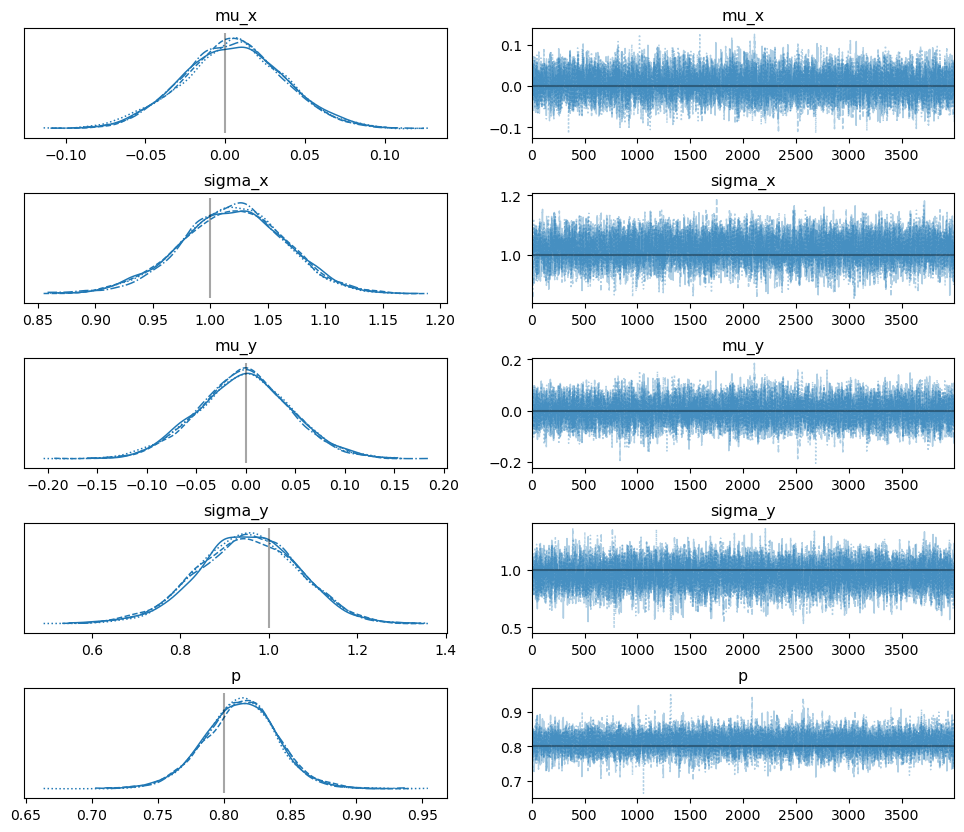

In [36]:
axes=az.plot_trace(            
        trace,
        compact=True,
        var_names=['mu_x', 'sigma_x','mu_y','sigma_y','p'],
        lines=[
            ('mu_x', {}, mu_t_x),         
            ('sigma_x', {}, sigma_t_x),   
            ('mu_y', {}, mu_t_y),         
            ('sigma_y', {}, sigma_t_y),
            ('p', {}, p_t)
        ]
    )
fig = axes.ravel()[0].figure.subplots_adjust(hspace=0.5)
az.summary(trace)

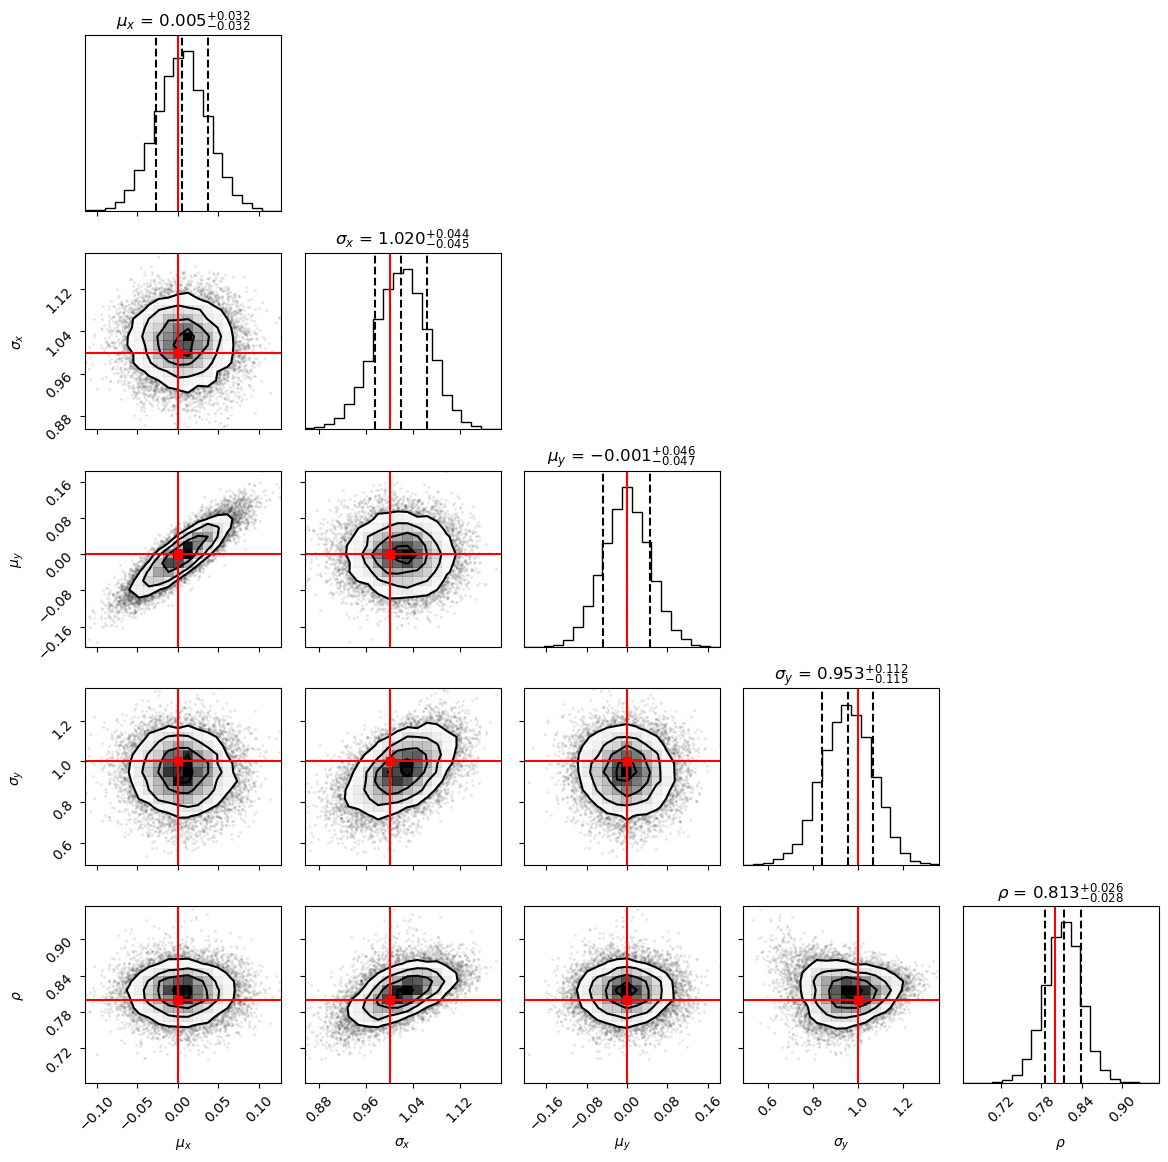

In [37]:

posterior=az.extract(trace,var_names=["mu_x","sigma_x","mu_y","sigma_y","p"],combined=True)

samples=np.column_stack([
posterior["mu_x"].values,
posterior["sigma_x"].values,
posterior["mu_y"].values,
posterior["sigma_y"].values,
posterior["p"].values
])

fig=corner.corner(
samples,
labels=[r"$\mu_x$",r"$\sigma_x$",r"$\mu_y$",r"$\sigma_y$",r"$\rho$"],
truths=[mu_t_x,sigma_t_x,mu_t_y,sigma_t_y,p_t],
truth_color="red",
show_titles=True,
quantiles=[0.16,0.5,0.84],
title_fmt=".3f"
)

plt.tight_layout()
plt.show()